# SEN1721 Travel Behaviour Research

## `In-class assignment 3:`
## `Latent class models`

**Delft University of Technology**<br>
**Q3 2026**<br>
**Instructor:** Sander van Cranenburgh<br>
**TA:**  Gabriel Nova <br>

### `Instructions`

**In-class assignments aim to:**<br>
* Illustrate how models and theory discussed in the classroom work out in practice.
* Help you gather hands-on modelling and data analysis skills.

**In-class assignments are:**<br>
* Learning environments where you work with Python and get support from TA and fellow students.
* Not graded and do not have to be submitted.

### `Use of AI tools`
AI tools, such as ChatGPT and Copilot, are great tools to assist with programming. Moreover, in your later careers, you will work in a world where such tools are widely available. As such, we **encourage** you to use AI tools **effectively**. However, be careful not to overestimate the capacity of AI tools! AI tools cannot replace you: you still have to conceptualise the problem, dissect it and structure it to conduct proper analysis. We recommend being especially **reticent** with using AI tools for the more conceptual and reflection-oriented questions. <br>

**`Learning objectives In-class assignment 3`**

After completing the in-class assignment, you will be able to:
1. Parameterise the class membership function with covariates


#### `Import packages`

To begin, we will import all the Python libraries that we will use in this assignment.

In [1]:
# Biogeme
import biogeme.database as db
import biogeme.biogeme as bio
from biogeme.expressions import Beta, PanelLikelihoodTrajectory

# Import custom estimation functions for Biogeme
from bio_estimation_fcns import estimate_LC, print_results

# General python packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from pathlib import Path
import seaborn as sns

# Random number generator
from random import random as rand
import random
random.seed(42)

# Pandas setting to show all columns when displaying a pandas dataframe
pd.set_option('display.max_columns', None)

### `1. Load the data set` <br>

In [2]:
# Create that path to the data file
data_path =  Path(f'data/Route_choice_data_cleaned.csv')

# Load the data as a pandas dataframe
df = pd.read_csv(data_path, sep=',')

# Sort the dataframe by ID and Quest to ensure that the choice tasks are in the correct order for each respondent.
# This is important for handling the panel structure of the data later.
df = df.sort_values(by=['ID', 'Quest'], ascending=[True, True])

# Show the first few rows of the data
df.head()

,Survey,ID,Quest,CHOICE,TT1,CONG1,VAR1,TC1,TT2,CONG2,VAR2,TC2,TT3,CONG3,VAR3,TC3,AV1,AV2,AV3,age,edu,edufin,sex,E1,E2,E3,E4,E5,E6,E7
351,2,1325,1,1,45,10,5,12.5,60,25,15,9.0,75,40,25,5.5,1,1,1,32,5,4,1,3,5,4,3,4,2,5
352,2,1325,2,3,75,25,15,12.5,45,40,25,9.0,60,10,5,5.5,1,1,1,32,5,4,1,3,5,4,3,4,2,5
353,2,1325,3,3,60,40,25,12.5,75,10,5,9.0,45,25,15,5.5,1,1,1,32,5,4,1,3,5,4,3,4,2,5
354,2,1325,4,1,60,25,5,9.0,75,40,15,5.5,45,10,25,12.5,1,1,1,32,5,4,1,3,5,4,3,4,2,5
355,2,1325,5,2,45,40,15,9.0,60,10,25,5.5,75,25,5,12.5,1,1,1,32,5,4,1,3,5,4,3,4,2,5


**Description of variables**<br>

The data contain (after cleaning) 3,474 stated route choices from 388 respondent. Each alternative is defined by four attributes: TT, CONG, VAR, and TC.
Below is a description of the variables in the data set. For more information about the data, you can have a look at the original paper by [Chorus et al. (2012)](https://link.springer.com/article/10.1007/s11116-012-9444-3). 


| Variable | Description                                                       | Data type                 |
|----------|-------------------------------------------------------------------|---------------------------|
| Survey   | Identifier for the survey                                         | Integer                   |
| ID       | Unique identifier for each respondent                             | Integer                   |
| Quest    | Order of the choice tasks per respondent                          | Integer                   |
| CHOICE   | Chosen alternative                                                | Integer                   |
| TT1      | Travel Time for Alternative 1                                     | Integer                   |
| CONG1    | Percentage of travel time in congestion for Alternative 1         | Integer                   |
| VAR1     | Travel time variability for Alternative 1                         | Integer                   |
| TC1      | Travel Cost for Alternative 1                                     | Float                     |
| TT2      | Travel Time for Alternative 2                                     | Integer                   |
| CONG2    | Percentage of travel time in congestion for Alternative 2         | Integer                   |
| VAR2     | Travel time variability for Alternative 2                         | Integer                   |
| TC2      | Travel Cost for Alternative 2                                     | Float                     |
| TT3      | Travel Time for Alternative 3                                     | Integer                   |
| CONG3    | Percentage of travel time in congestion for Alternative 3         | Integer                   |
| VAR3     | Travel time variability for Alternative 3                         | Integer                   |
| TC3      | Travel Cost for Alternative 3                                     | Float                     |
| AV1      | Availability of Alternative 1 (0: not available, 1: available)    | Integer                   |
| AV2      | Availability of Alternative 2 (0: not available, 1: available)    | Integer                   |
| AV3      | Availability of Alternative 3 (0: not available, 1: available)    | Integer                   |
| age      | Age of the respondent                                             | Integer                   |
| edu      | Educational level                                                 | Integer                   |
| edufin   | Max education level                                               | Integer                   |
| sex      | Gender of the respondent (e.g., male, female)                     | Integer                   |
| E1       | I considered it difficult to make choices across the presented alternatives in this choice experiment | Integer                   |
| E2       | I considered it important to make the ‘right’ choice across the presented alternatives                | Integer                   |
| E3       | When considering a new job or residential location, having a pleasant commute takes a central place in my decision | Integer      |
| E4       | In general, I think making choices is difficult                                                       | Integer                   |
| E5       | When decisions are important I consider making choices difficult                                      | Integer                   |
| E6       | When making choices, I consider the possibility that I will regret my choice in hindsight             | Integer                   |
| E7       | When making choices, I prefer a choice set that is as large as possible                               | Integer                   |

### `2. Exploring the covariates`

In this in-class assignment, we will use the covariates to parameterise the class membership model. Therefore, we will start by exploring the covariates in more detail. We will look at the distribution of the covariates and how they relate to each other.

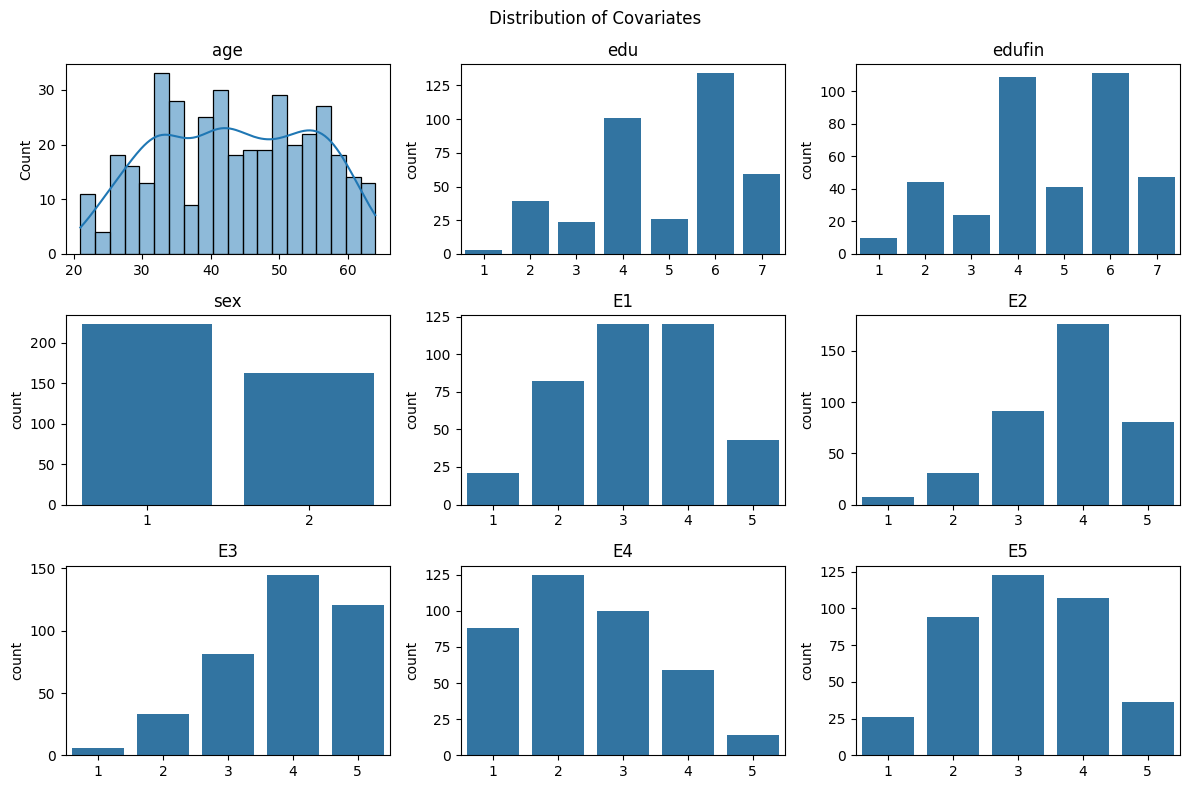

In [3]:
# Create a list with the covariates to explore
lst_covariates = ['age', 'edu', 'edufin','sex','E1','E2','E3','E4','E5']

# The covariates are the same for each choice task, so we can take the first row for each unique ID to get the covariate values for each individual. 
# This will give us a dataframe with one row per individual and the covariate values.
# First row for each unique ID
df_covar = df.groupby('ID').first()[lst_covariates]

# Plot the distribution of the nine covariates
fig, ax = plt.subplots(3,3,figsize=(12, 8))
ax = ax.flatten()
for i, cov in enumerate(lst_covariates):
    # For the age variable, we will plot a histogram. For the other categorical variables, we will plot a countplot to show the frequency of each category.
    if cov == "age":
        sns.histplot(df_covar[cov], bins=20, kde=True, ax=ax[i])
    else:
        sns.countplot(x=cov, data=df_covar, ax=ax[i])
    ax[i].set_title(cov)
    ax[i].set_xlabel('')

# Set the overall title for the figure
fig.suptitle('Distribution of Covariates')

# Adjust the layout to prevent overlap and show the plot
plt.tight_layout()
plt.show()

**Interpretation**<br>

        --> As can be seen, Age spreads from 18 to 80, with a mean of around 40. Education level seems to be quite high, probably it has oversampled higher educated people. In terms of the gender balance, we see that Male are overrepresented in the data set. Finally, intuitive results for the E1-E7 variables. For instance, in terms of E3, we see that most people consider a pleasant commute to be important when considering a new job or residential location.

**`Bivariate correlations between the covariates`**<br>

Next, it is useful to check the correlation between the covariates in your data set. We can use the `corr()` function from pandas to compute the correlation matrix, and show the correlation matrix using a heatmap.

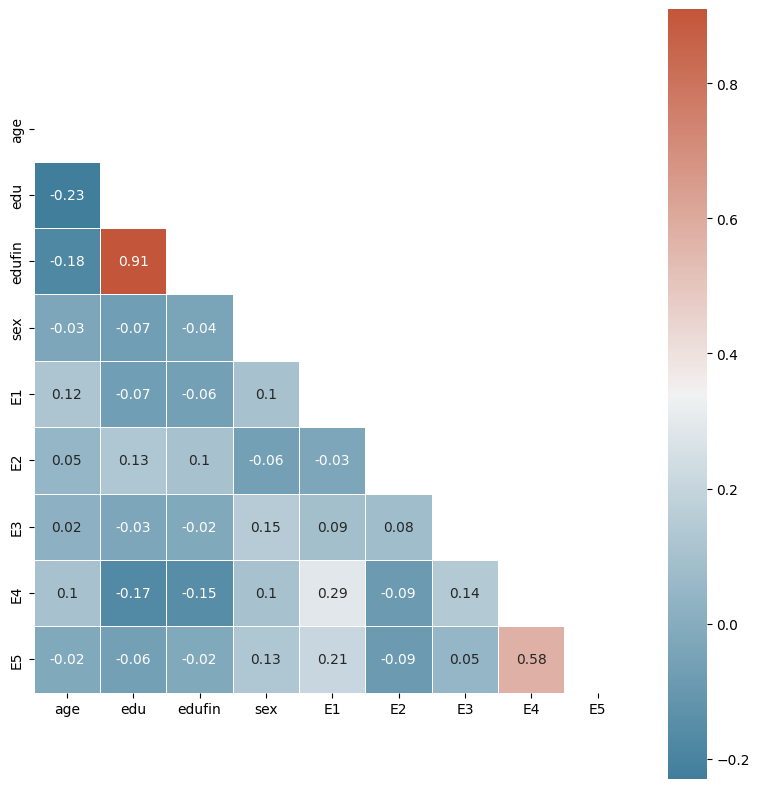

In [4]:
# heatmap of correlations
fig, ax = plt.subplots(figsize=(8, 8))
fig.set_tight_layout(True)

# Compute correlation matrix
corr = df_covar[lst_covariates].corr()

# Create upper triangular matrix to mask the upper triangular part of the heatmap
corr_mask = np.triu(np.ones_like(corr, dtype=bool))

# Generate a custom diverging colormap (because it looks better)
corr_cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Plot the heatmap
sns.heatmap(corr.round(2), mask=corr_mask, cmap=corr_cmap,
            annot=True, square=True, linewidths=.5, ax=ax)
plt.show()

**Interpretation**<br>

        --> As can be seen, the correlation in the data look fine. The correlation matrix shows that only `edu` and `edufin` are highly correlated (0.91). This is expected because `edufin` is the maximum educational level, and `edu` is the educational level of the respondent. The correlation matrix shows that none of the other variables highly correlate. This is good because it means none of the variables are not redundant. The second-highest correllation is between E4 and E5, but it is still only 0.57, which is not too high.

### `3. Creating Biogeme database and with covariates` <br>

**`Handling covariates with panel structure`** 

The covariate need some special handling because they are the same for each choice task. As you will see later, to use the covariates in the class membership function, we want to keep only **one** instance of these covariates per respondent. For each respondent, we keep the first row, and replace the cells in the remaining rows with ones.

In [5]:
# In the dataframe, we replace the cells with covariates with ones for all rows except the first one of each respondent.

# We loop over the covariates, and for each covariate, we use the `where()` function to keep the value of the covariate in the first row for each respondent (where `cumcount() == 0`).DS_Store
# We replace the value with one in the remaining rows (where `cumcount() != 0`).
for cov in lst_covariates:
    df[cov] = df[cov].where(df.groupby('ID').cumcount() == 0,1)

# Let's inspect our dataframe to see if the covariates if the first row with covariate values are retained and the cells in the remaining rows are replaced with ones.
df[['ID', 'Quest','CHOICE'] + lst_covariates].head(10)

,ID,Quest,CHOICE,age,edu,edufin,sex,E1,E2,E3,E4,E5
351,1325,1,1,32,5,4,1,3,5,4,3,4
352,1325,2,3,1,1,1,1,1,1,1,1,1
353,1325,3,3,1,1,1,1,1,1,1,1,1
354,1325,4,1,1,1,1,1,1,1,1,1,1
355,1325,5,2,1,1,1,1,1,1,1,1,1
356,1325,6,2,1,1,1,1,1,1,1,1,1
357,1325,7,3,1,1,1,1,1,1,1,1,1
358,1325,8,1,1,1,1,1,1,1,1,1,1
359,1325,9,3,1,1,1,1,1,1,1,1,1
369,1326,1,1,27,7,7,1,2,4,5,1,2


**`Database for panel models`** 

Next, we create the biogeme database which takes into account the **panel structure** of the data.

In [6]:
biodata_panel = db.Database('data_panel', df) # Creates a biogeme database with all the columns of the dataframe, including the covariates.
biodata_panel.panel("ID")                     # Specify that the panel structure is defined by "ID"

**`Biogeme variables`**<br>
Then, we make the variables in our data set globally available so we can use them in the estimation.<br>

In [7]:
# Create biogeme variables
global_vars = [] # Create an empty list to store the names of the global variables
for c in biodata_panel.data.columns:
    if biodata_panel.data[c].dtypes != 'object': # This excludes the 'object' type columns (these will throw an error when we try to create a global variable for them))
        globals()[c] = biodata_panel.variables[c] # Create a global variable with the same name as the column name in the dataframe, and assign it the corresponding biogeme variable.
        global_vars.append(c) # Add the variable name to the list of global variables
        
print(f"Global variables are created for:\n{global_vars}")

Global variables are created for:
['Survey', 'ID', 'Quest', 'CHOICE', 'TT1', 'CONG1', 'VAR1', 'TC1', 'TT2', 'CONG2', 'VAR2', 'TC2', 'TT3', 'CONG3', 'VAR3', 'TC3', 'AV1', 'AV2', 'AV3', 'age', 'edu', 'edufin', 'sex', 'E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7']


### `4. Parameterisation of the class membership function using covariates` <br>

In in-class assignment 2, we decided to go with the 3-class model. Now, we want to parameterise the class membership function using covariates.<br> 
We start by trying to see whether respondent's **education** (`edu`) helps to explain the class membership (and thus explaintheir tastes).

In [8]:
# Give a name to the model    
model_name = 'LC with 3 classes with education as covariate'

# Define the model parameters for class 0
B_tt_0    = Beta('B_tt_0',  0, None, None, 0)
B_cong_0  = Beta('B_cong_0',0, None, None, 0)
B_var_0   = Beta('B_var_0', 0, None, None, 0)
B_tc_0    = Beta('B_tc_0',  0, None, None, 0)

# Define the model parameters for class 1
B_tt_1    = Beta('B_tt_1',  0, None, None, 0)
B_cong_1  = Beta('B_cong_1',0, None, None, 0)
B_var_1   = Beta('B_var_1', 0, None, None, 0)
B_tc_1    = Beta('B_tc_1',  0, None, None, 0)

# Define the model parameters for class 2
B_tt_2    = Beta('B_tt_2',  0, None, None, 0)
B_cong_2  = Beta('B_cong_2',0, None, None, 0)
B_var_2   = Beta('B_var_2', 0, None, None, 0)
B_tc_2    = Beta('B_tc_2',  0, None, None, 0)

# Define the membership model parameters
delta_0  = Beta('delta_0', 0   , None, None, 1)
delta_1  = Beta('delta_1', 0.10, None, None, 0)
delta_2  = Beta('delta_2',-0.10, None, None, 0)
gamma_edu_1 = Beta('gamma_edu_1', 0, None, None, 0)
gamma_edu_2 = Beta('gamma_edu_2', 0, None, None, 0)

# Define the utility functions for class 0
V1_0 = B_tt_0 * TT1 + B_cong_0 * CONG1 + B_var_0 * VAR1 + B_tc_0 * TC1
V2_0 = B_tt_0 * TT2 + B_cong_0 * CONG2 + B_var_0 * VAR2 + B_tc_0 * TC2
V3_0 = B_tt_0 * TT3 + B_cong_0 * CONG3 + B_var_0 * VAR3 + B_tc_0 * TC3

# Define the utility functions for class 1
V1_1 = B_tt_1 * TT1 + B_cong_1 * CONG1 + B_var_1 * VAR1 + B_tc_1 * TC1
V2_1 = B_tt_1 * TT2 + B_cong_1 * CONG2 + B_var_1 * VAR2 + B_tc_1 * TC2
V3_1 = B_tt_1 * TT3 + B_cong_1 * CONG3 + B_var_1 * VAR3 + B_tc_1 * TC3

# Define the utility functions for class 2
V1_2 = B_tt_2 * TT1 + B_cong_2 * CONG1 + B_var_2 * VAR1 + B_tc_2 * TC1
V2_2 = B_tt_2 * TT2 + B_cong_2 * CONG2 + B_var_2 * VAR2 + B_tc_2 * TC2
V3_2 = B_tt_2 * TT3 + B_cong_2 * CONG3 + B_var_2 * VAR3 + B_tc_2 * TC3

# Associate utility functions with the numbering of alternatives in the "choice" column
V_0 = {1: V1_0, 2: V2_0, 3: V3_0}
V_1 = {1: V1_1, 2: V2_1, 3: V3_1}
V_2 = {1: V1_2, 2: V2_2, 3: V3_2}

# Put the dictionary of utility functions in a list
V = [V_0, V_1, V_2]

# Create a dictionary to describe the availability conditions of each alternative, where 1 indicates that the alternative is available, and 0 indicates that the alternative is not available.
AV = {1: AV1, 2: AV2, 3: AV3} 

# Define the membership model value functions for each class
# The term "PanelLikelihoodTrajectory()" is needed to make it compatible with the panel structure of the data.
# "PanelLikelihoodTrajectory(arg)" multiplies the argument over all rows in the database for each individual. 
# Since we replaced the covariate with ones for all choice tasks except the first one for each respondent, 
# it effectively just takes the value of the covariate and multiplies it with ones for the remaining choice tasks, which does not change the value of the covariate.
nu_0 = delta_0 # Note: one class needs to be fixed to 0. delta_0 is fixed to 0
nu_1 = delta_1 + gamma_edu_1 * PanelLikelihoodTrajectory(edu)
nu_2 = delta_2 + gamma_edu_2 * PanelLikelihoodTrajectory(edu)

# Put membership functions in a list
nu = [nu_0, nu_1, nu_2]

In [9]:
# Estimate the LC model
results_LC_edu = estimate_LC(V,AV,nu,CHOICE,biodata_panel,model_name)

# Print the results
print_results(results_LC_edu)



Results for model LC with 3 classes with education as covariate
Nbr of parameters             :       16
Sample size                   :      386
Observations                  :     3474
Excluded data                 :        0
Null log likelihood           : -3816.58
Final log likelihood          : -2354.21
Likelihood ratio test (null)  :  2924.73
Rho square (null)             :     0.38
Rho bar square (null)         :     0.38
Akaike Information Criterion  :  4740.42
Bayesian Information Criterion:  4803.72

Estimates of the parameters:
               Value  Rob. Std err  Rob. t-test  Rob. p-value
B_cong_0    -0.0432        0.0047        -9.19          0.00
B_cong_1    -0.0083        0.0051        -1.63          0.10
B_cong_2    -0.0364        0.0073        -4.98          0.00
B_tc_0      -0.3447        0.0311       -11.08          0.00
B_tc_1      -0.1179        0.0261        -4.52          0.00
B_tc_2      -0.0640        0.0229        -2.79          0.01
B_tt_0      -0.0699      

**Interpretation of the estimation results**

        --> The estimation results show that the education level of the respondent is a significant predictor of the class membership. The higher the education level, the less likely the respondent is to belong to class 2.

        --> There is no strict ordering of the classes. Every time we estimate the model, the order of the classes can change. This is a common property of latent class models, and it is important to keep in mind when interpreting the results. For instance, it seems that class 0 and class 1 of in-class assignment 2 have switched places. This does not mean that the classes themselves have changed, but only that their order in the output has changed.

        --> In general, the covariates in LC choice models are often found to only weakly explain the class membership. However, even if the covariates are not statistically significant, the LC model still provides key behavioural insights into the taste heterogeneity in the population.

### `Exercise 1:  Testing covariates `<br>

`A.` Re-estimate the 2-class LC model using gender (i.e. `sex`) as a covariate<br>
`B.` Re-estimate the 2-class LC model using education (`edu`) as a covariate, but considering education as a binary variable: {edu<=4: "low", edu> 4: "high"}<br>
Hint: To do so, you can simply add the logical operator inside the PanelLikelihoodTrajectory(`edu`<=4) term.<br>
`C.` Compare the results (fit and estimates) of the three models with covariates (i.e. `edu`, `sex`, `edu`<=4). Which model is better? Why? 
`D.` Try to extend the model with both `sex` and `edu` as covariates. Does this improve the model fit? Why (not)?

In [10]:
# A) Re-estimate the 2-class LC model using gender (i.e. sex) as a covariate

# Give a name to the model    
model_name = 'LC with 3 classes with sex as covariate'

# Define the model parameters for class 0
B_tt_0    = Beta('B_tt_0',  0, None, None, 0)
B_cong_0  = Beta('B_cong_0',0, None, None, 0)
B_var_0   = Beta('B_var_0', 0, None, None, 0)
B_tc_0    = Beta('B_tc_0',  0, None, None, 0)

# Define the model parameters for class 1
B_tt_1    = Beta('B_tt_1',  0, None, None, 0)
B_cong_1  = Beta('B_cong_1',0, None, None, 0)
B_var_1   = Beta('B_var_1', 0, None, None, 0)
B_tc_1    = Beta('B_tc_1',  0, None, None, 0)

# Define the model parameters for class 2
B_tt_2    = Beta('B_tt_2',  0, None, None, 0)
B_cong_2  = Beta('B_cong_2',0, None, None, 0)
B_var_2   = Beta('B_var_2', 0, None, None, 0)
B_tc_2    = Beta('B_tc_2',  0, None, None, 0)

# Define the membership model parameters
delta_0  = Beta('delta_0', 0   , None, None, 1)
delta_1  = Beta('delta_1', 0.10, None, None, 0)
delta_2  = Beta('delta_2',-0.10, None, None, 0)
gamma_sex_1 = Beta('gamma_sex_1', 0, None, None, 0)
gamma_sex_2 = Beta('gamma_sex_2', 0, None, None, 0)

# Define the utility functions for class 0
V1_0 = B_tt_0 * TT1 + B_cong_0 * CONG1 + B_var_0 * VAR1 + B_tc_0 * TC1
V2_0 = B_tt_0 * TT2 + B_cong_0 * CONG2 + B_var_0 * VAR2 + B_tc_0 * TC2
V3_0 = B_tt_0 * TT3 + B_cong_0 * CONG3 + B_var_0 * VAR3 + B_tc_0 * TC3

# Define the utility functions for class 1
V1_1 = B_tt_1 * TT1 + B_cong_1 * CONG1 + B_var_1 * VAR1 + B_tc_1 * TC1
V2_1 = B_tt_1 * TT2 + B_cong_1 * CONG2 + B_var_1 * VAR2 + B_tc_1 * TC2
V3_1 = B_tt_1 * TT3 + B_cong_1 * CONG3 + B_var_1 * VAR3 + B_tc_1 * TC3

# Define the utility functions for class 2
V1_2 = B_tt_2 * TT1 + B_cong_2 * CONG1 + B_var_2 * VAR1 + B_tc_2 * TC1
V2_2 = B_tt_2 * TT2 + B_cong_2 * CONG2 + B_var_2 * VAR2 + B_tc_2 * TC2
V3_2 = B_tt_2 * TT3 + B_cong_2 * CONG3 + B_var_2 * VAR3 + B_tc_2 * TC3

# Associate utility functions with the numbering of alternatives in the "choice" column
V_0 = {1: V1_0, 2: V2_0, 3: V3_0}
V_1 = {1: V1_1, 2: V2_1, 3: V3_1}
V_2 = {1: V1_2, 2: V2_2, 3: V3_2}

# Put the dictionary of utility functions in a list
V = [V_0, V_1, V_2]

# Create a dictionary to describe the availability conditions of each alternative, where 1 indicates that the alternative is available, and 0 indicates that the alternative is not available.
AV = {1: AV1, 2: AV2, 3: AV3} 

# Define the membership model value functions for each class
nu_1 = delta_1 + gamma_sex_1 * PanelLikelihoodTrajectory(sex)
nu_2 = delta_2 + gamma_sex_2 * PanelLikelihoodTrajectory(sex)

# Put membership functions in a list
nu = [nu_0, nu_1, nu_2]

# Estimate the LC model
results_LC_sex = estimate_LC(V,AV,nu,CHOICE,biodata_panel,model_name)

# Print the results
print_results(results_LC_sex)



Results for model LC with 3 classes with sex as covariate
Nbr of parameters             :       16
Sample size                   :      386
Observations                  :     3474
Excluded data                 :        0
Null log likelihood           : -3816.58
Final log likelihood          : -2360.87
Likelihood ratio test (null)  :  2911.42
Rho square (null)             :     0.38
Rho bar square (null)         :     0.38
Akaike Information Criterion  :  4753.73
Bayesian Information Criterion:  4817.03

Estimates of the parameters:
               Value  Rob. Std err  Rob. t-test  Rob. p-value
B_cong_0    -0.0428        0.0047        -9.04          0.00
B_cong_1    -0.0090        0.0052        -1.73          0.08
B_cong_2    -0.0372        0.0067        -5.53          0.00
B_tc_0      -0.3567        0.0330       -10.80          0.00
B_tc_1      -0.1144        0.0261        -4.39          0.00
B_tc_2      -0.0742        0.0207        -3.58          0.00
B_tt_0      -0.0732        0.00

In [11]:
# B) Re-estimate the 2-class LC model using education as a covariate, but considering education as a binary variable

# Give a name to the model    
model_name = 'LC with 3 classes with education as a binary as covariate'

# Define the model parameters for class 0
B_tt_0    = Beta('B_tt_0',  0, None, None, 0)
B_cong_0  = Beta('B_cong_0',0, None, None, 0)
B_var_0   = Beta('B_var_0', 0, None, None, 0)
B_tc_0    = Beta('B_tc_0',  0, None, None, 0)

# Define the model parameters for class 1
B_tt_1    = Beta('B_tt_1',  0, None, None, 0)
B_cong_1  = Beta('B_cong_1',0, None, None, 0)
B_var_1   = Beta('B_var_1', 0, None, None, 0)
B_tc_1    = Beta('B_tc_1',  0, None, None, 0)

# Define the model parameters for class 2
B_tt_2    = Beta('B_tt_2',  0, None, None, 0)
B_cong_2  = Beta('B_cong_2',0, None, None, 0)
B_var_2   = Beta('B_var_2', 0, None, None, 0)
B_tc_2    = Beta('B_tc_2',  0, None, None, 0)

# Define the membership model parameters
delta_0  = Beta('delta_0', 0   , None, None, 1)
delta_1  = Beta('delta_1', 0.10, None, None, 0)
delta_2  = Beta('delta_2',-0.10, None, None, 0)
gamma_edulow_1 = Beta('gammalow_edu_1', 0, None, None, 0)
gamma_edulow_2 = Beta('gammalow_edu_2', 0, None, None, 0)

# Define the utility functions for class 0
V1_0 = B_tt_0 * TT1 + B_cong_0 * CONG1 + B_var_0 * VAR1 + B_tc_0 * TC1
V2_0 = B_tt_0 * TT2 + B_cong_0 * CONG2 + B_var_0 * VAR2 + B_tc_0 * TC2
V3_0 = B_tt_0 * TT3 + B_cong_0 * CONG3 + B_var_0 * VAR3 + B_tc_0 * TC3

# Define the utility functions for class 1
V1_1 = B_tt_1 * TT1 + B_cong_1 * CONG1 + B_var_1 * VAR1 + B_tc_1 * TC1
V2_1 = B_tt_1 * TT2 + B_cong_1 * CONG2 + B_var_1 * VAR2 + B_tc_1 * TC2
V3_1 = B_tt_1 * TT3 + B_cong_1 * CONG3 + B_var_1 * VAR3 + B_tc_1 * TC3

# Define the utility functions for class 2
V1_2 = B_tt_2 * TT1 + B_cong_2 * CONG1 + B_var_2 * VAR1 + B_tc_2 * TC1
V2_2 = B_tt_2 * TT2 + B_cong_2 * CONG2 + B_var_2 * VAR2 + B_tc_2 * TC2
V3_2 = B_tt_2 * TT3 + B_cong_2 * CONG3 + B_var_2 * VAR3 + B_tc_2 * TC3

# Associate utility functions with the numbering of alternatives in the "choice" column
V_0 = {1: V1_0, 2: V2_0, 3: V3_0}
V_1 = {1: V1_1, 2: V2_1, 3: V3_1}
V_2 = {1: V1_2, 2: V2_2, 3: V3_2}

# Put the dictionary of utility functions in a list
V = [V_0, V_1, V_2]

# Create a dictionary to describe the availability conditions of each alternative, where 1 indicates that the alternative is available, and 0 indicates that the alternative is not available.
AV = {1: AV1, 2: AV2, 3: AV3} 

# Define the membership model value functions for each class
nu_1 = delta_1 + gamma_edulow_1 * PanelLikelihoodTrajectory(edu<=4)
nu_2 = delta_2 + gamma_edulow_2 * PanelLikelihoodTrajectory(edu<=4)

# Put membership functions in a list
nu = [nu_0, nu_1, nu_2]

# Estimate the LC model
results_LC_edulow = estimate_LC(V,AV,nu,CHOICE,biodata_panel,model_name)

# Print the results
print_results(results_LC_edulow)



Results for model LC with 3 classes with education as a binary as covariate
Nbr of parameters             :       16
Sample size                   :      386
Observations                  :     3474
Excluded data                 :        0
Null log likelihood           : -3816.58
Final log likelihood          : -2358.65
Likelihood ratio test (null)  :  2915.86
Rho square (null)             :     0.38
Rho bar square (null)         :     0.38
Akaike Information Criterion  :  4749.30
Bayesian Information Criterion:  4812.60

Estimates of the parameters:
                  Value  Rob. Std err  Rob. t-test  Rob. p-value
B_cong_0       -0.0430        0.0047        -9.22          0.00
B_cong_1       -0.0085        0.0051        -1.65          0.10
B_cong_2       -0.0369        0.0070        -5.27          0.00
B_tc_0         -0.3505        0.0327       -10.72          0.00
B_tc_1         -0.1172        0.0260        -4.50          0.00
B_tc_2         -0.0692        0.0236        -2.93       

In [ ]:
# C) Compare the results (fit and estimates) of the three models with covariates (i.e. edu, sex, edu<=2). Which model is better? Why? 
print(f" LL 3-class LC no covariates:\t{-2362.45}")
print(f" LL 3-class LC edu:\t\t LL = {np.round(results_LC_edu.get_general_statistics()['Final log likelihood'][0],2)} | BIC = {np.round(results_LC_edu.get_general_statistics()['Bayesian Information Criterion'][0],2)}")
print(f" LL 3-class LC sex:\t\t LL = {np.round(results_LC_sex.get_general_statistics()['Final log likelihood'][0],2)} | BIC = {np.round(results_LC_sex.get_general_statistics()['Bayesian Information Criterion'][0],2)}")
print(f" LL 3-class LC edulow:\t\t LL = {np.round(results_LC_edulow.get_general_statistics()['Final log likelihood'][0],2)} | BIC = {np.round(results_LC_edulow.get_general_statistics()['Bayesian Information Criterion'][0],2)}")

# The LC with model edu as an ordinal variable has the highest log-likelihood value, which indicates that it is the best model among the three. 
# Also, this model is the only model where the covariate is significant.

 LL 3-class LC no covariates:	-2362.45
 LL 3-class LC edu:		 LL = -2354.21 | BIC = 4803.72
 LL 3-class LC sex:		 LL = -2360.87 | BIC = 4817.03
 LL 3-class LC edulow:		 LL = -2358.65 | BIC = 4812.6
 LL 3-class LC edu_sex:		 LL = -2352.12 | BIC = 4811.45


In [20]:
# Give a name to the model    
model_name = 'LC with 3 classes with education as covariate'

# Define the model parameters for class 0
B_tt_0    = Beta('B_tt_0',  0, None, None, 0)
B_cong_0  = Beta('B_cong_0',0, None, None, 0)
B_var_0   = Beta('B_var_0', 0, None, None, 0)
B_tc_0    = Beta('B_tc_0',  0, None, None, 0)

# Define the model parameters for class 1
B_tt_1    = Beta('B_tt_1',  0, None, None, 0)
B_cong_1  = Beta('B_cong_1',0, None, None, 0)
B_var_1   = Beta('B_var_1', 0, None, None, 0)
B_tc_1    = Beta('B_tc_1',  0, None, None, 0)

# Define the model parameters for class 2
B_tt_2    = Beta('B_tt_2',  0, None, None, 0)
B_cong_2  = Beta('B_cong_2',0, None, None, 0)
B_var_2   = Beta('B_var_2', 0, None, None, 0)
B_tc_2    = Beta('B_tc_2',  0, None, None, 0)

# Define the membership model parameters
delta_0  = Beta('delta_0', 0   , None, None, 1)
delta_1  = Beta('delta_1', 0.10, None, None, 0)
delta_2  = Beta('delta_2',-0.10, None, None, 0)
gamma_edu_1 = Beta('gamma_edu_1', 0, None, None, 0)
gamma_edu_2 = Beta('gamma_edu_2', 0, None, None, 0)

# Define the utility functions for class 0
V1_0 = B_tt_0 * TT1 + B_cong_0 * CONG1 + B_var_0 * VAR1 + B_tc_0 * TC1
V2_0 = B_tt_0 * TT2 + B_cong_0 * CONG2 + B_var_0 * VAR2 + B_tc_0 * TC2
V3_0 = B_tt_0 * TT3 + B_cong_0 * CONG3 + B_var_0 * VAR3 + B_tc_0 * TC3

# Define the utility functions for class 1
V1_1 = B_tt_1 * TT1 + B_cong_1 * CONG1 + B_var_1 * VAR1 + B_tc_1 * TC1
V2_1 = B_tt_1 * TT2 + B_cong_1 * CONG2 + B_var_1 * VAR2 + B_tc_1 * TC2
V3_1 = B_tt_1 * TT3 + B_cong_1 * CONG3 + B_var_1 * VAR3 + B_tc_1 * TC3

# Define the utility functions for class 2
V1_2 = B_tt_2 * TT1 + B_cong_2 * CONG1 + B_var_2 * VAR1 + B_tc_2 * TC1
V2_2 = B_tt_2 * TT2 + B_cong_2 * CONG2 + B_var_2 * VAR2 + B_tc_2 * TC2
V3_2 = B_tt_2 * TT3 + B_cong_2 * CONG3 + B_var_2 * VAR3 + B_tc_2 * TC3

# Associate utility functions with the numbering of alternatives in the "choice" column
V_0 = {1: V1_0, 2: V2_0, 3: V3_0}
V_1 = {1: V1_1, 2: V2_1, 3: V3_1}
V_2 = {1: V1_2, 2: V2_2, 3: V3_2}

# Put the dictionary of utility functions in a list
V = [V_0, V_1, V_2]

# Create a dictionary to describe the availability conditions of each alternative, where 1 indicates that the alternative is available, and 0 indicates that the alternative is not available.
AV = {1: AV1, 2: AV2, 3: AV3} 

# Define the membership model value functions for each class
# The term "PanelLikelihoodTrajectory()" is needed to make it compatible with the panel structure of the data.
# "PanelLikelihoodTrajectory(arg)" multiplies the argument over all rows in the database for each individual. 
# Since we replaced the covariate with ones for all choice tasks except the first one for each respondent, 
# it effectively just takes the value of the covariate and multiplies it with ones for the remaining choice tasks, which does not change the value of the covariate.
nu_0 = delta_0 # Note: one class needs to be fixed to 0. delta_0 is fixed to 0
nu_1 = delta_1 + gamma_edu_1 * PanelLikelihoodTrajectory(edu) + gamma_sex_1 * PanelLikelihoodTrajectory(sex)
nu_2 = delta_2 + gamma_edu_2 * PanelLikelihoodTrajectory(edu) + gamma_sex_2 * PanelLikelihoodTrajectory(sex)

# Put membership functions in a list
nu = [nu_0, nu_1, nu_2]


# Estimate the LC model
results_LC_edu_sex = estimate_LC(V,AV,nu,CHOICE,biodata_panel,model_name)

# Print the results
print_results(results_LC_edu_sex)



Results for model LC with 3 classes with education as covariate
Nbr of parameters             :       18
Sample size                   :      386
Observations                  :     3474
Excluded data                 :        0
Null log likelihood           : -3816.58
Final log likelihood          : -2352.12
Likelihood ratio test (null)  :  2928.91
Rho square (null)             :     0.38
Rho bar square (null)         :     0.38
Akaike Information Criterion  :  4740.25
Bayesian Information Criterion:  4811.45

Estimates of the parameters:
               Value  Rob. Std err  Rob. t-test  Rob. p-value
B_cong_0    -0.0431        0.0047        -9.22          0.00
B_cong_1    -0.0086        0.0052        -1.66          0.10
B_cong_2    -0.0362        0.0072        -5.03          0.00
B_tc_0      -0.3440        0.0307       -11.22          0.00
B_tc_1      -0.1162        0.0262        -4.43          0.00
B_tc_2      -0.0649        0.0228        -2.85          0.00
B_tt_0      -0.0702      

In [23]:
print(f" LL 3-class LC edu_sex:\t\t LL = {np.round(results_LC_edu_sex.get_general_statistics()['Final log likelihood'][0],2)} | BIC = {np.round(results_LC_edu_sex.get_general_statistics()['Bayesian Information Criterion'][0],2)}")


 LL 3-class LC edu_sex:		 LL = -2352.12 | BIC = 4811.45


In [24]:
# C Combining edu and sex slightly improves the log-likelihood compared to the model with only edu, but the improvement is very small and not worth the additional complexity of the model. The BIC has deteriorated as compare to the model with only edu.